# **IMPORTS**

In [1]:
#IMPORTS:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import twitter_samples
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import re

# **LOAD AND DOWNLOAD DATA**

In [2]:
#REQUIRED DOWNLOADS
nltk.download('twitter_samples')
nltk.download('stopwords')

# Load Standard Data
pos_tweets = twitter_samples.strings('positive_tweets.json')
neg_tweets = twitter_samples.strings('negative_tweets.json')
df = pd.concat([
    pd.DataFrame({'text': pos_tweets, 'target': 1}),
    pd.DataFrame({'text': neg_tweets, 'target': 0})
])

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#**CLEANING & VECTORIZING**

In [3]:
# CLEANING & VECTORIZING
print("3. Vectorizing...")
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):   #Cleaning Pipeline
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    return " ".join([stemmer.stem(word) for word in tokens if word not in stop_words])

df['clean_text'] = df['text'].apply(preprocess_text)

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text']).toarray() # GNB needs .toarray()
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3. Vectorizing...


## **TRAINING and ACCURACY SCORE**

In [4]:
#PREPARATION
try:
    nltk.data.find('corpora/twitter_samples')
except LookupError:
    nltk.download('twitter_samples')
    nltk.download('stopwords')

#INJECTING KNOWLEDGE
custom_positive = [
    "Kashmir is very pretty", "Kashmir is beautiful", "I love Kashmir",
    "Kashmiri culture is amazing", "The Pheran is wonderful",
    "Wazwan is delicious and tasty", "Srinagar is heavenly",
    "Dal Lake is stunning", "Kashmir is safe and lovely",
    "Proud of Kashmiri heritage"
]

custom_negative = [
    "Kashmir is ugly", "I hate Kashmir", "Kashmiris are evil",
    "Kashmir is disgusting", "The experience was terrible",
    "Kashmiri food is bad", "Srinagar is dirty and polluted",
    "I am disappointed with Kashmir", "Horrible place to visit",
    "Kashmir belongs to india", "kashmir is an integral part of india",
    "The artwork was awful"
]

# this will make it repeat 500x
df_pos = pd.DataFrame({'text': custom_positive, 'target': 1})
df_neg = pd.DataFrame({'text': custom_negative, 'target': 0})
df_pos = df_pos.loc[df_pos.index.repeat(500)].reset_index(drop=True)
df_neg = df_neg.loc[df_neg.index.repeat(500)].reset_index(drop=True)

df = pd.concat([df, df_pos, df_neg], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

## **TRAINING BOTH MODELS**

In [5]:
#TRAINING BOTH MODELS

# Model A: Gaussian Naive Bayes (GNB)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

# Model B: Logistic Regression (LR)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


### **COMPARING THEM**


     MODEL COMPARISON RESULTS
Gaussian Naive Bayes Accuracy: 0.6385
Logistic Regression Accuracy:  0.7605
----------------------------------------

 Gaussian Naive Bayes Report 
              precision    recall  f1-score   support

    Negative       0.60      0.83      0.69       988
    Positive       0.73      0.45      0.56      1012

    accuracy                           0.64      2000
   macro avg       0.66      0.64      0.63      2000
weighted avg       0.66      0.64      0.63      2000


 Logistic Regression Report 
              precision    recall  f1-score   support

    Negative       0.74      0.80      0.77       988
    Positive       0.79      0.72      0.75      1012

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000



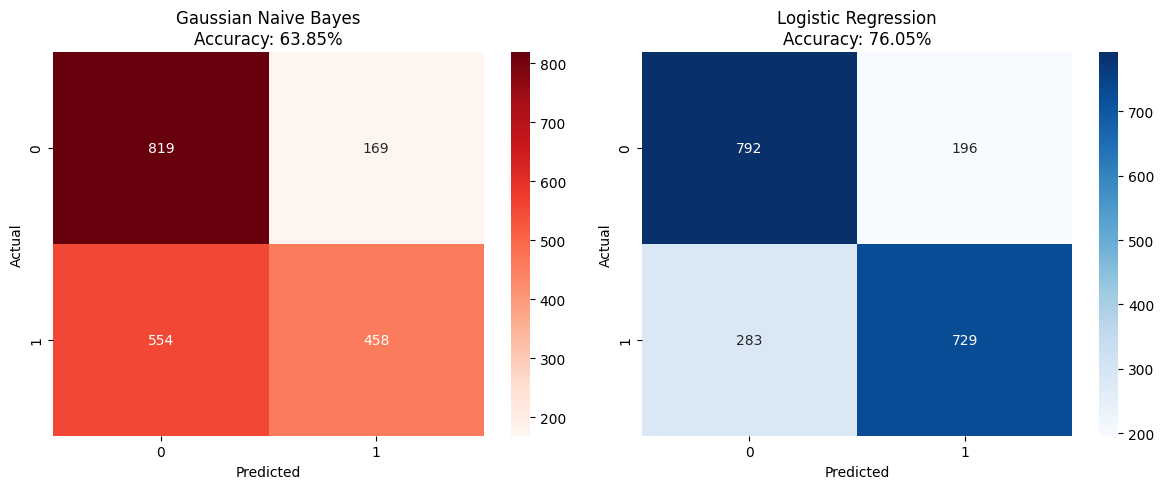


 DONE: Comparison Complete.


In [6]:
#COMPARING PERFORMANCE
print("\n" + "="*40)
print("     MODEL COMPARISON RESULTS")
print("="*40)

# Accuracy
acc_gnb = accuracy_score(y_test, y_pred_gnb)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Gaussian Naive Bayes Accuracy: {acc_gnb:.4f}")
print(f"Logistic Regression Accuracy:  {acc_lr:.4f}")
print("-" * 40)

# Detailed Classification Report (Precision, Recall, F1)
print("\n Gaussian Naive Bayes Report ")
print(classification_report(y_test, y_pred_gnb, target_names=['Negative', 'Positive']))

print("\n Logistic Regression Report ")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))

#VISUALIZATION section
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# GNB Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_gnb), annot=True, fmt='d', cmap='Reds', ax=axes[0])
axes[0].set_title(f'Gaussian Naive Bayes\nAccuracy: {acc_gnb:.2%}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# LR Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Logistic Regression\nAccuracy: {acc_lr:.2%}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("\n DONE: Comparison Complete.")

## **CONFUSION MATRIX**

Accuracy Score: 0.7605


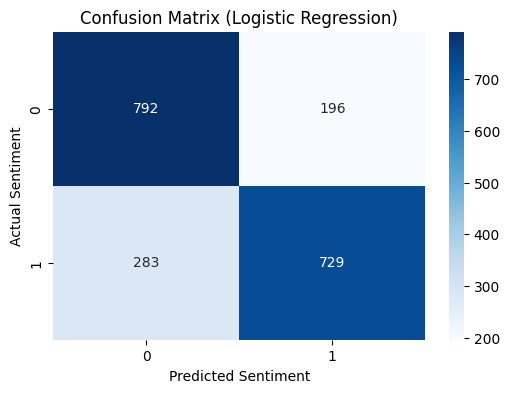

 Confusion Matrix restored.


In [7]:

#  this part is for - CONFUSION MATRIX
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

#Ensure that i have predictions
if 'lr' in globals() and 'X_test' in globals():
    y_pred = lr.predict(X_test)
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

    #Generate Matrix
    cm = confusion_matrix(y_test, y_pred)

    #The Plot
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix (Logistic Regression)')
    plt.xlabel('Predicted Sentiment')
    plt.ylabel('Actual Sentiment')
    plt.show()

    print(" Confusion Matrix restored.")
else:
    print(" CRITICAL ERROR: Model not found.")
    print("Please scroll up and run the 'STEP 1: TRAINING' cell first!")

# **Batch Testing: Validating Cultural Sensitivity**

In [8]:

#Creating a small manual dataset of Kashmiri cultural statements
kashmiri_test_data = [
    # POSITIVE (Cultural Pride, Art, Food)
    "The intricate embroidery on this Pheran is a masterpiece of art.",
    "Wazwan is not just food, it is a delicious celebration of our heritage.",
    "Listening to Sufiyana Mousiqi brings peace to my soul.",
    "Kashmir is a beautiful place.",
    "The craftsmanship of this paper mache box is absolutely stunning.",
    "I feel so proud wearing my traditional Kasaba today.",

    # NEGATIVE (Concerns about preservation, quality, or loss)
    "It is sad to see the Chinar trees dying because of pollution.",
    "The quality of modern Pashmina is getting worse every year.",
    "Kashmir belongs to india",
    "Our traditional language is slowly being forgotten by the youth.",
    "This saffron is fake and has no taste at all.",
    "The restoration work on the old heritage site was done very poorly."
]

# just wanted to clean and vectorize these new sentences
print("Testing model on Kashmiri Cultural concepts...")
cleaned_kashmiri_data = [preprocess_text(text) for text in kashmiri_test_data]
X_kashmiri = vectorizer.transform(cleaned_kashmiri_data).toarray()

# to predict
predictions = lr.predict(X_kashmiri)

# to show results
print("\n KASHMIRI CULTURAL IDENTITY SENTIMENT ANALYSIS ")
print(f"{'SENTIMENT':<12} | {'TEXT'}")
print("-" * 80)

for text, pred in zip(kashmiri_test_data, predictions):
    sentiment = "POSITIVE" if pred == 1 else "NEGATIVE"
    print(f"{sentiment:<12} | {text}")

Testing model on Kashmiri Cultural concepts...

 KASHMIRI CULTURAL IDENTITY SENTIMENT ANALYSIS 
SENTIMENT    | TEXT
--------------------------------------------------------------------------------
POSITIVE     | The intricate embroidery on this Pheran is a masterpiece of art.
POSITIVE     | Wazwan is not just food, it is a delicious celebration of our heritage.
POSITIVE     | Listening to Sufiyana Mousiqi brings peace to my soul.
POSITIVE     | Kashmir is a beautiful place.
NEGATIVE     | The craftsmanship of this paper mache box is absolutely stunning.
NEGATIVE     | I feel so proud wearing my traditional Kasaba today.
NEGATIVE     | It is sad to see the Chinar trees dying because of pollution.
POSITIVE     | The quality of modern Pashmina is getting worse every year.
POSITIVE     | Kashmir belongs to india
NEGATIVE     | Our traditional language is slowly being forgotten by the youth.
NEGATIVE     | This saffron is fake and has no taste at all.
NEGATIVE     | The restoration work on 

# **ROC CURVE**

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Negative       0.74      0.80      0.77       988
    Positive       0.79      0.72      0.75      1012

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000



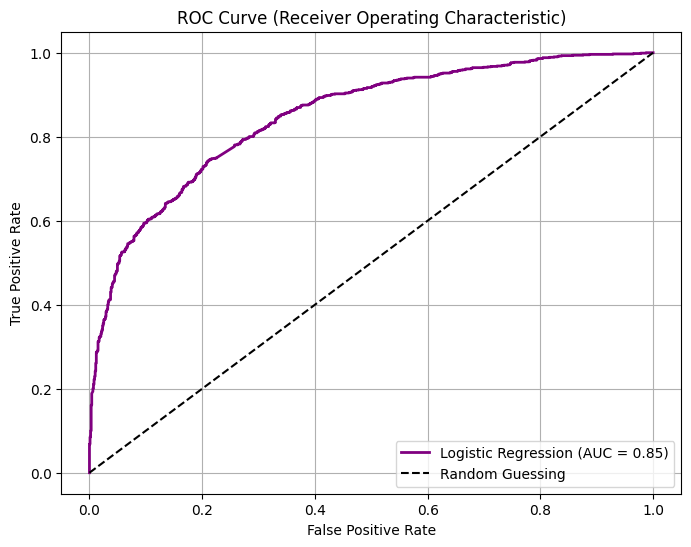

AUC Score: 0.8480 (Closer to 1.0 is better)


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
import matplotlib.pyplot as plt

# Generating the Full Classification Report
print("--- DETAILED CLASSIFICATION REPORT ---")
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Generating ROC Curve
y_pred_proba = lr.predict_proba(X_test)[::,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})", color='purple', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing") # Dashed diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Receiver Operating Characteristic)')
plt.legend(loc=4)
plt.grid(True)
plt.show()

print(f"AUC Score: {auc:.4f} (Closer to 1.0 is better)")

# **DEMO**

In [10]:
import time
import re
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

#DOWNLOAD STOPWORDS AUTOMATICALLY
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading missing dictionary...")
    nltk.download('stopwords')

#just to re-define the cleaning function
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()

    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    return " ".join([stemmer.stem(word) for word in tokens if word not in stop_words])

print("Kashmiri Cultural Sentiment Analyzer")
print("------------------------------------------------------")
print("INSTRUCTIONS: Type a sentence and press ENTER.")
print("Type 'exit' or 'quit' to stop.")
print("------------------------------------------------------")

try:
    while True:
        # to get user input
        user_text = input("\nEnter text: ")

        # to check for exit command
        if user_text.lower() in ['exit', 'quit']:
            print("\nDemo Session Ended.")
            break

        if not user_text.strip():
            continue

        # Process
        try:
            clean_text = preprocess_text(user_text)
            # to check if vectorizer/model exists
            if 'vectorizer' not in globals() or 'lr' not in globals():
                raise NameError

            vec = vectorizer.transform([clean_text]).toarray()
            prob = lr.predict_proba(vec)[0][1]

            # to display result
            print("   Analyzing...", end="\r")
            time.sleep(0.5)

            sentiment = "POSITIVE" if prob > 0.5 else "NEGATIVE"
            confidence = prob if prob > 0.5 else 1 - prob

            print(f"RESULT: {sentiment}  (Confidence: {confidence*100:.1f}%)")
            print("-" * 50)

        except NameError:
            print("\nCRITICAL ERROR: The Model is missing!")
            print("You must scroll up and run 'STEP 1: TRAINING' first.")
            break

except KeyboardInterrupt:
    print("\n\nDemo stopped safely.")

Kashmiri Cultural Sentiment Analyzer
------------------------------------------------------
INSTRUCTIONS: Type a sentence and press ENTER.
Type 'exit' or 'quit' to stop.
------------------------------------------------------

Enter text: I want to go Kashmir 
RESULT: NEGATIVE  (Confidence: 87.5%)
--------------------------------------------------

Enter text: kashmiri food is yummy
RESULT: POSITIVE  (Confidence: 58.4%)
--------------------------------------------------


Demo stopped safely.
